# Sistema de Agrupación de Casas — K-Means

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle
import urllib.request
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Carga del dataset

In [2]:
url = 'https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv'
ruta = '../data/raw/housing.csv'
os.makedirs(os.path.dirname(ruta), exist_ok=True)

if not os.path.exists(ruta):
    urllib.request.urlretrieve(url, ruta)

df = pd.read_csv(ruta)
print(f'Dimensiones: {df.shape}')
print(df.columns.tolist())
df.head()

Dimensiones: (20640, 9)
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. EDA — solo las columnas que necesitamos

In [3]:
# Solo usamos Latitude, Longitude y MedInc según las instrucciones
cols = ['Latitude', 'Longitude', 'MedInc']
df = df[cols].dropna()
print(f'Filas tras eliminar nulos: {len(df)}')
df.describe()

Filas tras eliminar nulos: 20640


,Latitude,Longitude,MedInc
count,20640.000000,20640.000000,20640.000000
mean,35.631861,-119.569704,3.870671
std,2.135952,2.003532,1.899822
min,32.540000,-124.350000,0.499900
25%,33.930000,-121.800000,2.563400
50%,34.260000,-118.490000,3.534800
75%,37.710000,-118.010000,4.743250
max,41.950000,-114.310000,15.000100


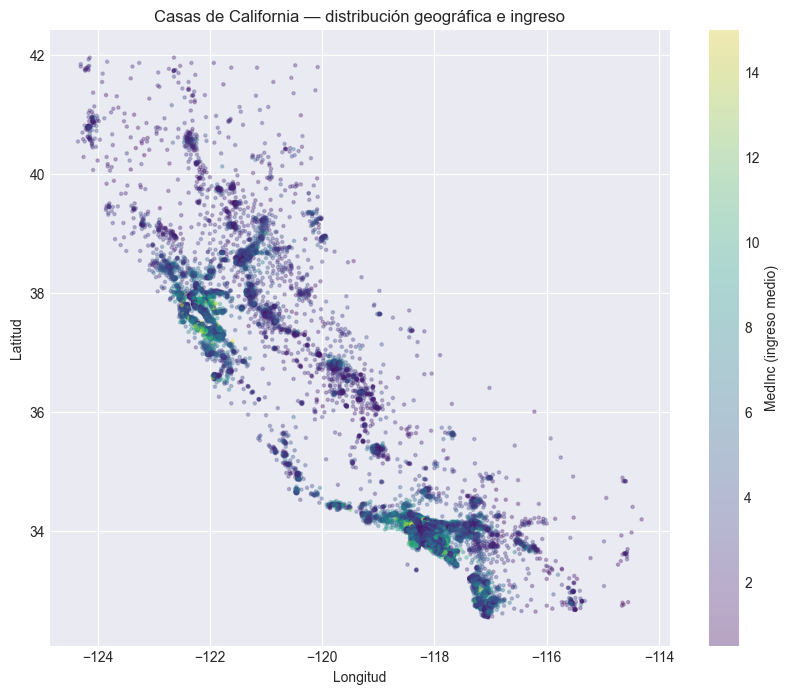

In [4]:
# Visualizar la distribución geográfica coloreada por ingreso medio
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                      c=df['MedInc'], cmap='viridis', alpha=0.3, s=5)
plt.colorbar(scatter, label='MedInc (ingreso medio)')
plt.title('Casas de California — distribución geográfica e ingreso')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

## 3. Split y escalado

In [5]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 16512 | Test: 4128


## 4. K-Means con 6 clusters

In [6]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_train_sc)

# Añadir el cluster como columna
X_train_cl = X_train.copy()
X_train_cl['cluster'] = kmeans.labels_

print('Distribución de casas por cluster:')
print(X_train_cl['cluster'].value_counts().sort_index())

Distribución de casas por cluster:
cluster
0    1321
1    3380
2     453
3    3931
4    2239
5    5188
Name: count, dtype: int64


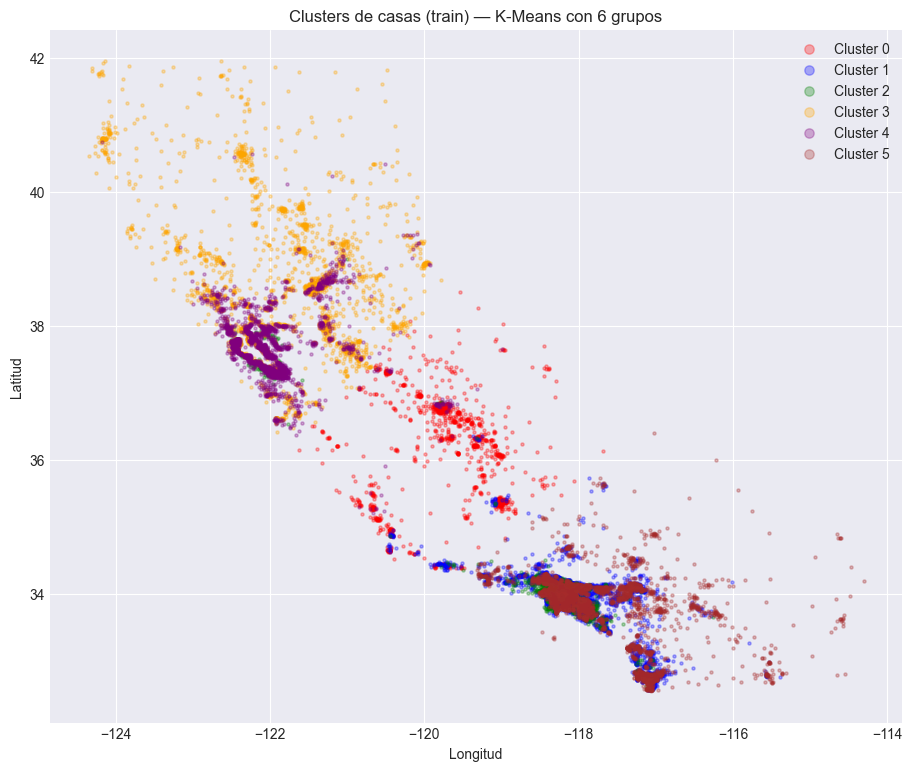

In [7]:
# Graficar los clusters en el mapa
colores = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
plt.figure(figsize=(11, 9))

for cluster_id in range(6):
    mask = X_train_cl['cluster'] == cluster_id
    plt.scatter(X_train_cl.loc[mask, 'Longitude'],
                X_train_cl.loc[mask, 'Latitude'],
                c=colores[cluster_id], alpha=0.3, s=5,
                label=f'Cluster {cluster_id}')

plt.title('Clusters de casas (train) — K-Means con 6 grupos')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(markerscale=3)
plt.show()

## 5. Predecir clusters del conjunto de test

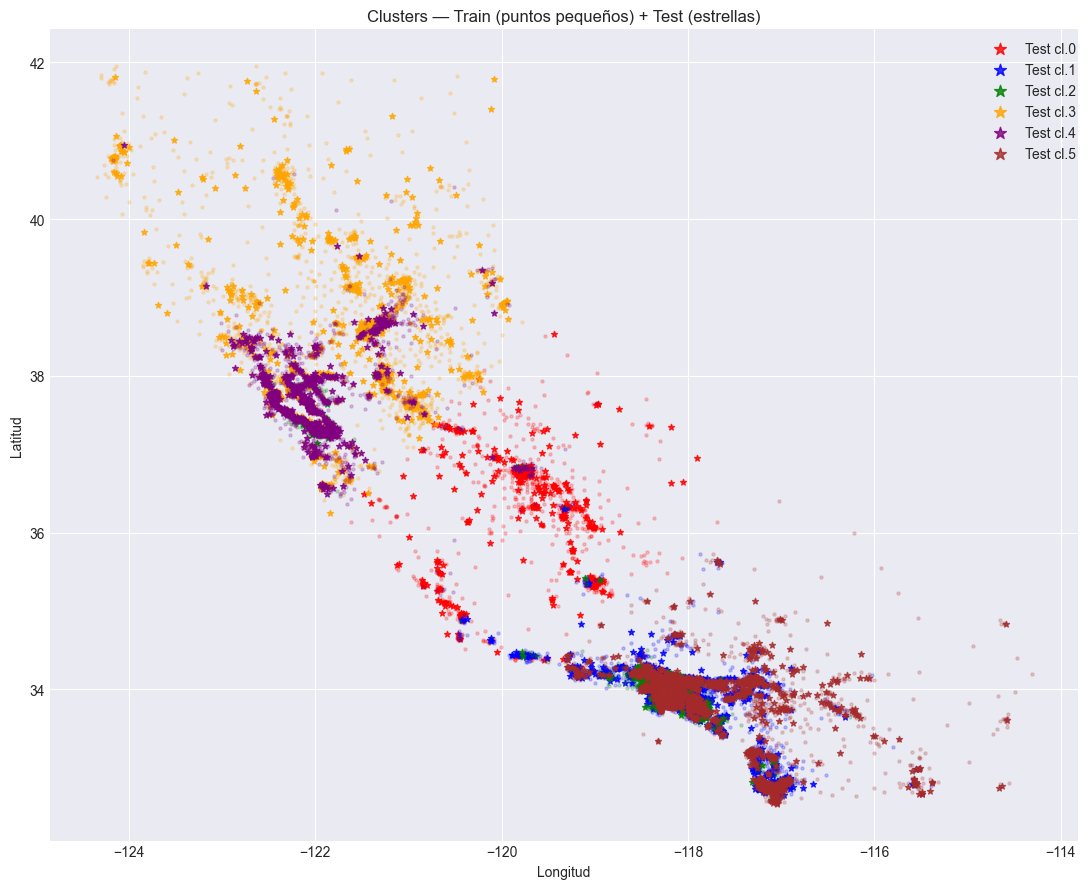

Las estrellas caen dentro de sus clusters correspondientes → predicción satisfactoria


In [8]:
X_test_cl = X_test.copy()
X_test_cl['cluster'] = kmeans.predict(X_test_sc)

# Gráfico con train + test superpuestos
plt.figure(figsize=(11, 9))

for cluster_id in range(6):
    mask_tr = X_train_cl['cluster'] == cluster_id
    mask_te = X_test_cl['cluster'] == cluster_id
    plt.scatter(X_train_cl.loc[mask_tr, 'Longitude'],
                X_train_cl.loc[mask_tr, 'Latitude'],
                c=colores[cluster_id], alpha=0.2, s=5)
    plt.scatter(X_test_cl.loc[mask_te, 'Longitude'],
                X_test_cl.loc[mask_te, 'Latitude'],
                c=colores[cluster_id], alpha=0.8, s=20, marker='*',
                label=f'Test cl.{cluster_id}')

plt.title('Clusters — Train (puntos pequeños) + Test (estrellas)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(markerscale=2, bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

print('Las estrellas caen dentro de sus clusters correspondientes → predicción satisfactoria')

## 6. Modelo de clasificación supervisada sobre las etiquetas del K-Means

In [9]:
# Ahora que tenemos etiquetas (cluster), entrenamos un clasificador supervisado
# Features: Latitude, Longitude, MedInc | Target: cluster
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_sc, X_train_cl['cluster'])

y_pred = clf.predict(X_test_sc)
acc = accuracy_score(X_test_cl['cluster'], y_pred)
print(f'Accuracy del clasificador supervisado: {acc:.4f}')
print('\nClassification Report:')
print(classification_report(X_test_cl['cluster'], y_pred,
                             target_names=[f'Cluster {i}' for i in range(6)]))

Accuracy del clasificador supervisado: 0.9952

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.99      0.99      0.99       337
   Cluster 1       1.00      1.00      1.00       829
   Cluster 2       1.00      0.98      0.99       112
   Cluster 3       0.99      0.99      0.99       962
   Cluster 4       0.99      1.00      0.99       514
   Cluster 5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



In [10]:
# Ingreso medio promedio por cluster para interpretar qué representa cada grupo
resumen = X_train_cl.groupby('cluster')[['Latitude', 'Longitude', 'MedInc']].mean()
print('Características promedio por cluster:')
print(resumen.round(3))

Características promedio por cluster:
         Latitude  Longitude  MedInc
cluster                             
0          36.082   -119.728   2.625
1          33.868   -118.024   5.312
2          34.901   -119.237  10.444
3          38.346   -121.901   2.835
4          37.702   -121.939   5.518
5          33.816   -117.817   2.781


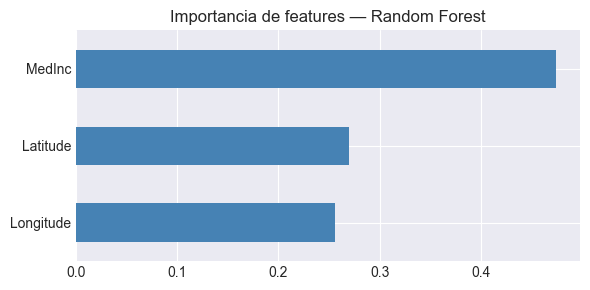

In [11]:
# Importancia de features en el clasificador
importancias = pd.Series(clf.feature_importances_, index=cols).sort_values(ascending=True)
plt.figure(figsize=(6, 3))
importancias.plot(kind='barh', color='steelblue')
plt.title('Importancia de features — Random Forest')
plt.tight_layout()
plt.show()

## 7. Guardar modelos

In [12]:
os.makedirs('../../models', exist_ok=True)

with open('../../models/kmeans_casas.pkl', 'wb') as f:
    pickle.dump({'kmeans': kmeans, 'scaler': scaler}, f)

with open('../../models/clf_casas.pkl', 'wb') as f:
    pickle.dump(clf, f)

print('Modelos guardados: models/kmeans_casas.pkl y models/clf_casas.pkl')

Modelos guardados: models/kmeans_casas.pkl y models/clf_casas.pkl
